# Lab 3: Mine Crafting


As with previous labs, be sure to submit only the `lab3.ipynb` and `lab3.html` version of the lab in your github `Lab3` folder. No more, and no less.

## Introduction

Imagine you are a scientist for a mining company that operates a vertical mine at the Earth's
equator. This is one of the deepest mines on Earth; it's roughly 4 km to the bottom of the shaft.
Your boss proposes to measure the vertical depth of the shaft by dropping a 1 kg test mass and
accurately measuring the time to hit the bottom.

You will be guided in your investigations below and submit your report in the form of this notebook. Be sure to be quantitative in nature, produce highly polished plots, with appropriate titles, units, etc.


A table of relevant physical constants is below. Good luck!

| Quantity | Value |
|----------|-------|
|  Gravitational Constant ($G$)        |  $6.6743 \times 10^{-11}$ m$^3$/kg/s$^2$  | 
|  Gravitational Acceleration ($g_o$)  |  9.81 m/s$^2$ (approximate) | 
|  Mass of the Earth ($M_{\oplus}$)    |  $5.972 \times 10^{24}$ kg      | 
|  Mass of the Moon ($M_{m}$)          |  $7.35 \times 10^{22}$ kg     | 
|  Radius of the Earth ($R_{\oplus}$)  |  6378.1 km     | 
|  Radius of the Moon ($R_{m}$)        |   1738.1 km    | 
|  Earth's Rotation Rate at the Equator| $7.272 \times 10^{-5} $ rad/s  | 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.integrate import quad
from scipy.fft import rfft, rfftfreq

G = 6.6743e-11 # Gravitational Constant     (m^3/kg/s^2)
g_0 = 9.81     # Gravitational Acceleration (m/s^2)
M_E = 5.972e24 # Mass of the Earth          (kg)
M_m = 7.35e22  # Mass of the Moon           (kg)
R_E = 6378.1e3 # Radius of the Earth        (m)
R_m = 1738.1e3 # Radius of the Moon         (m)
w_E = 7.272e-5 # Earth's Rotation Rate at the Equator (rad/s)

## Part 1: The Ideal Case

In this section and the following sections, we calculate the time for the 1 kg test mass to reach the bottom of the mineshaft under a series of increasingly complex assumptions. Remember that a projectile experiencing a constant gravitational force, plus a drag force, obeys the following second
order differential equation:

$$
\frac{d^2y}{dt^2} = -g + \alpha \left| \frac{dy}{dt} \right|^{\gamma}
\tag{1}
$$



where $t$ is time, $y$ is the height, $g$ is the gravitational acceleration,
$\alpha$ is the drag coefficient, and $\gamma$ is the speed dependence
of the drag. For example, for $\gamma=2$, the drag force grows proportionally
to the speed *squared*.  **Hint**: pay particular attention to the sign
conventions in your implementation! The drag, by definition, should *oppose*
the direction of motion.

1. First, make a simple calculation of how long a test mass would 
            take to reach the bottom of the 4km shaft assuming no drag. This is the simple
            free-fall algebraic expression you know from PHYS 171.

2. Next, reduce (1) into a *system* of coupled
            first order differential equations by setting the velocity $v = dy/dt$.

3. Numerically solve (1) using `solve_ivp` assuming $\alpha=0$.
            Plot the position and velocity as a function of time.                              
            Draw a horizontal dashed line at the depth of the bottom of the shaft,
            to make it easy to see.
            Make the plot look nice, including displaying the position on the left axes,
            and plotting the velocity on a second right axis, using matplotlib `twinx`
            capability.        
   In your notebook, label this figure clearly as **Figure 1**.

4. Using the `events` detection capability of `solve_ivp`,
            calculate the time at which the mass hits the bottom of the shaft
            in the case of zero drag ($\alpha=0$). Compare this to your analytic calculation
            and discuss any differences you might see.


In [2]:
d = 4e3 # length of shaft (m)
t_kinematic = np.sqrt(2*d/g_0)
print(f"Fall time: {t_kinematic:.3f} seconds")

Fall time: 28.557 seconds


In [3]:
# Velocity derivative ODE
def vel_deriv(t, init, alpha, gamma):
    y, v = init
    dydt = v                               # rate of change of depth
    dvdt = -g_0 + alpha*(np.abs(v)**gamma) # rate of change of velocity
    return (dydt, dvdt)

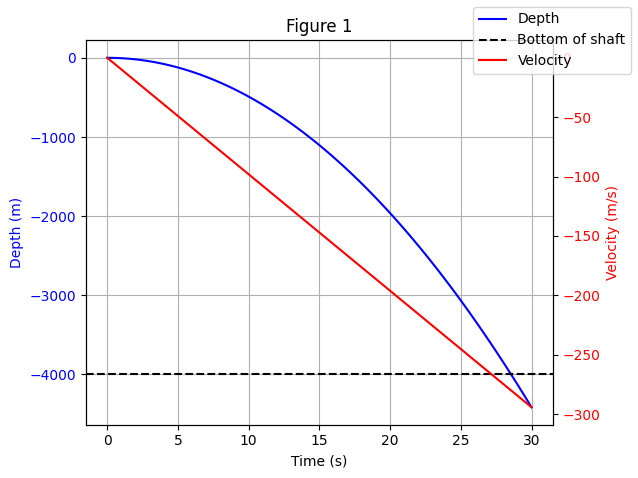

In [4]:
# Assign variables
t_0, t_f = 0, 30
tt = np.linspace(t_0, t_f, 101)
y_0 = 0     # initial depth
v_0 = 0     # iniital velocity
alpha_0 = 0 # drag coefficient
gamma_0 = 1 # speed dependence of drag

# solve_ivp
soln = solve_ivp(vel_deriv, (t_0, t_f), [y_0, v_0], args=(alpha_0, gamma_0), t_eval=tt)
t_vals = soln.t    # time
y_vals = soln.y[0] # depth
v_vals = soln.y[1] # velocity

# Plot
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

ax1.plot(t_vals, y_vals, "b", label="Depth")
ax2.plot(t_vals, v_vals, "r", label="Velocity")
ax1.axhline(-d, c="k", ls="--", label="Bottom of shaft")

# Label
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Depth (m)", c="b")
ax2.set_ylabel("Velocity (m/s)", c="r")

ax1.tick_params(axis="y", labelcolor="b")
ax2.tick_params(axis="y", labelcolor="r")

ax1.set_title("Figure 1")
ax1.grid(True)
fig.legend(loc="upper right")
fig.tight_layout()

In [5]:
# Event trigger
def bottom(t, init, alpha, gamma):
    y, v = init
    return y + d

# solve_ivp
soln = solve_ivp(vel_deriv, (t_0, t_f), [y_0, v_0], args=(alpha_0, gamma_0), t_eval=tt, events=bottom)
t_soln = soln.t_events[0][0]

# Print results
print(f"Analytic time: {t_kinematic:.3f} seconds")
print(f"Numeric time:  {t_soln:.3f} seconds")

Analytic time: 28.557 seconds
Numeric time:  28.557 seconds


The numeric result of the solve_ivp is the same as the analytic result found by the kinematic equation.

## Part 2: Including Drag and a Variable g

In practice, we cannot ignore drag, and we should also not assume that $g$ is a constant. If you
approximate that the mass of the Earth is distributed homogenously (which it is not!), then the
gravitational constant $g$ will depend on your distance $r$ from the center of the Earth in a simple
linear way:

$$
 g(r) = g_o \left( \frac{r}{R_{\oplus}} \right)
 \tag{2}
$$

where $g_o$ is the gravity at the surface, and $R_{\oplus}$ is the radius of the Earth.

1. Make a new plot that shows the velocity and position as a function of                       
            time assuming $g(y)$. Be careful with coordinate systems!
            The test mass' position should be at the Earth radius at $t=0$, and falling down.
            But for plotting purposes, it will be useful to plot the height
            above the bottom of the shaft.        
            In your notebook, label this figure clearly as **Figure 2**.

2. What effect does incorporating a height-dependent $g$ have on the fall time? Explain.

3. Now, turn on drag, and replot the position and velocity.
            For most things, $\gamma=2$ is a good assumption.
            How can you calibrate the value of $\alpha$? Think about what we did in Lecture 15/16,
            where we assumed a sky-diver's terminal speed was 50 m/s.
            You should assume the same of the test mass.
            What affect does including drag have on the fall time?



Fall time: 83.542 seconds


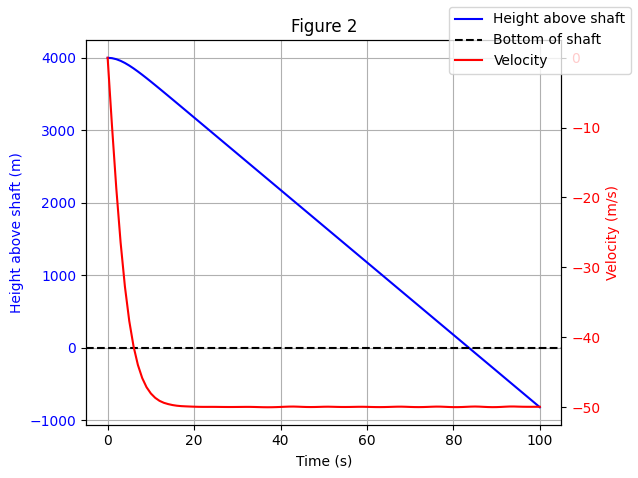

In [6]:
# Velocity derivative ODE (with height-dependent g)
def vel_deriv(t, init, alpha, gamma):
    y, v = init
    g = g_0 * (R_E+y)/R_E                # height-dependent g
    dydt = v                             # rate of change of depth
    dvdt = -g + alpha*(np.abs(v)**gamma) # rate of change of velocity
    return (dydt, dvdt)
    
# Assign variables
t_0, t_f = 0, 100
tt = np.linspace(t_0, t_f, 101)

# Find drag coefficient
v_terminal = 50 # terminal velocity
gamma_0 = 2     # speed dependence of drag
alpha_0 = g_0 / v_terminal**gamma_0 # drag coefficient

# solve_ivp
soln = solve_ivp(vel_deriv, (t_0, t_f), [y_0, v_0], args=(alpha_0, gamma_0), t_eval=tt, events=bottom)
t_vals = soln.t        # time
y_vals = soln.y[0] + d # height above bottom of shaft
v_vals = soln.y[1]     # velocity

t_soln = soln.t_events[0][0]
print(f"Fall time: {t_soln:.3f} seconds")

# Plot
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

ax1.plot(t_vals, y_vals, "b", label="Height above shaft")
ax2.plot(t_vals, v_vals, "r", label="Velocity")
ax1.axhline(0, c="k", ls="--", label="Bottom of shaft")

# Label
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Height above shaft (m)", c="b")
ax2.set_ylabel("Velocity (m/s)", c="r")

ax1.tick_params(axis="y", labelcolor="b")
ax2.tick_params(axis="y", labelcolor="r")

ax1.set_title("Figure 2")
ax1.grid(True)
fig.legend(loc="upper right")
fig.tight_layout()

The effect of incorporating the time-dependent g is negligble considering how small the mine shaft is compared to the radius of the earth. The fall time will be slightly longer, but not enough for a noticeable difference. Fall time increases to 28.558 seconds from 28.557 seconds.

The effect of incorporating drag considerably increases the fall time. This is because the velocity increases at a decreasing rate, eventually approaching a terminal velocity of 50 m/s.

Overall, the result is a new fall time of 83.542 seconds.

## Part 3: The Coriolis Force

Since the Earth is rotating, there is a Coriolis force on the test mass as it falls.
The force can be quite large.
For example, imagine the mine shaft is on the Earth's equator and pointed towards
the Earth's center.
The equator rotates at about half a kilometer per second.
So once the test mass has fallen for some time, it will bump into the wall,
unless the shaft is very wide.
The Coriolis force $\vec{F_c}$ is:

$$
 \vec{F_c} = -2m \, \left( \vec{\Omega} \times \vec{v} \right)
 \tag{3}
$$

where $\vec{\Omega}$ is the Earth's rotation rate for a vector along $\hat{z}$ and $m$ is the mass of the object (1 kg for the test mass in this case).
For a mine shaft on the equator, we might pick a right-handed coordinate system
with the $\hat{x}$ axis along the East, $\hat{y}$ down into the mine shaft,
and $\hat{z}$ along the North.
This implies the component of the force are:

\begin{equation}
        F_{c_x} = + 2m \, \Omega v_y     \tag{4}
\end{equation}
\begin{equation}
        F_{c_y} = - 2m \, \Omega v_x     \tag{5}
\end{equation}
\begin{equation}
        F_{c_z} = 0     \tag{6}
\end{equation}

1. Extend and update your differential equations of motion 
                to include the Coriolis force. You will need to add a Coriolis
                acceleration term to your equation for the depth coordinate (remember, $F=ma$),
                and additionally, start tracking the velocity and position 
                in the transverse direction (``side-to-side'' in the shaft).

2. Plot the transverse position of the object as a function of depth, initially assuming $\alpha=0$.
                        That is, both axes will have units of distance. 
                Plot ``dots" every few seconds so that you can see
                how the particle moves over time.
                Note that your depth and transverse axes are likely to have very
                different length scales.
                The depth will have a range of 4 km,
   while the transverse direction is about 5m.       
                In your report, this should be **Figure 3**.                

3. If the mine shaft is 5m wide, and you drop the test mass 
                        from the center, does the test mass reach the bottom?
                Or does it bump into the wall first?

4. Now turn drag back on. Does drag make any difference here?




Fall time:   75.460 seconds
Final speed: 49.982 m/s
Final height: -3596.077 m


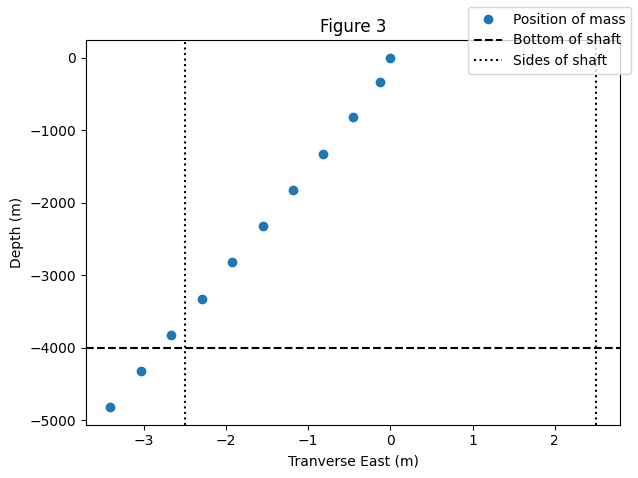

In [7]:
# Velocity derivative ODE (with heigh-dependent g and Coriolis Force)
def vel_deriv(t, init, alpha, gamma):
    y, vy, x, vx = init
    v = np.sqrt(vy**2 + vx**2) # speed
    g = g_0 * (R_E+y)/R_E      # height-dependent g
    
    dydt = vy # rate of change of depth      (y vector)
    dxdt = vx # rate of change of transverse (x vector)

    # Avoid divide by zero error
    if v != 0:
        dvydt = -g + 2*w_E*vx - alpha*(v**gamma)*vy/v # rate of change of velocity (y vector)
        dvxdt = 2*w_E*vy - alpha*(v**gamma)*vx/v      # rate of change of velocity (x vector)
    else:
        dvydt = -g + 2*w_E*vx # rate of change of velocity (y vector)
        dvxdt = 2*w_E*vy      # rate of change of velocity (x vector)
    
    return (dydt, dvydt, dxdt, dvxdt)

# Event trigger
def bottom(t, init, alpha, gamma):
    y, vy, x, vx = init
    return x + 2.5

# Assign timeframe
t_0, t_f = 0, 100 # 100
tt = np.linspace(t_0, t_f, 11)

# Initial conditions
y_0 = 0  # initial depth      (y vector)
vy_0 = 0 # iniital velocity   (y vector)
x_0 = 0  # initial transverse (x vector)
vx_0 = 0 # iniital velocity   (x vector)

# solve_ivp
soln = solve_ivp(vel_deriv, (t_0, t_f), [y_0, vy_0, x_0, vx_0], args=(alpha_0, gamma_0), t_eval=tt, events=bottom)
t_vals  = soln.t    # time
y_vals  = soln.y[0] # depth      (y vector)
x_vals  = soln.y[2] # transverse (x vector)

t_soln = soln.t_events[0][0]
y_soln = soln.y_events[0][0][0]
v_soln = np.sqrt((soln.y_events[0][0][1])**2 + (soln.y_events[0][0][3])**2)
print(f"Fall time:   {t_soln:.3f} seconds")
print(f"Final speed: {v_soln:.3f} m/s")
print(f"Final height: {y_soln:.3f} m")

# Plot
fig, ax = plt.subplots()
ax.plot(x_vals, y_vals, "o", label="Position of mass")
ax.axhline(-d, c="k", ls="--", label="Bottom of shaft")
ax.axvline(2.5, c="k", ls=":", label="Sides of shaft")
ax.axvline(-2.5, c="k", ls=":")

# Label
ax.set_xlabel("Tranverse East (m)")
ax.set_ylabel("Depth (m)")

ax.set_title("Figure 3")
ax1.grid(True)
fig.legend(loc="upper right")
fig.tight_layout()

If the drag force is not included, the mass hits the sides of the shaft before it hits the bottom. This occurs after 21.907 seconds at a depth of -2353.932 m. If the drag force is included, the mass still hits the side of the shaft but after 75.460 seconds and at a depth of -3596.077 m.

## Part 4: An infinitely deep mine


Now, let us consider the theoretical case of an infinitely deep mine -- that is,
a tunnel which traverses the full diameter of the Earth.
For convenience, imagine the tunnel goes from pole-to-pole,
such that $\vec{\Omega} \times \vec{v} = 0$, and the Coriolis force
can be neglected, as well as the drag force.

Additionally, continue assuming a constant density Earth.

1. Again, plot the depth and velocity as a function of time.
               (Be careful with the meaning of $y$, as the particle can theoretically
                traverse fully through to the other side of the Earth.)
                Comment on what you see in the graph.       
                In your notebook, label this figure clearly as **Figure 4**.                

2. How long will it take for the object to reach the other side? 
                At what time does the object reach the center of the Earth,
                and at what speed?

3. How does this ``crossing-time" compare to the orbital period, where you assume
                the object is on a circular orbit, in centripetal balance
                with the attractive force of the gravity.
                \begin{equation}
                        \frac{v^2}{R} = \frac{GM}{R^2}   \tag{7}
                \end{equation}
                gives the orbital speed $v$ for a given Earth radius $R$ and 
                Earth mass $M$.





Time to center:  1266.473 seconds
Time to surface: 2532.947 seconds
Speed at center: 7910.760 m/s
Period:          5065.894 seconds


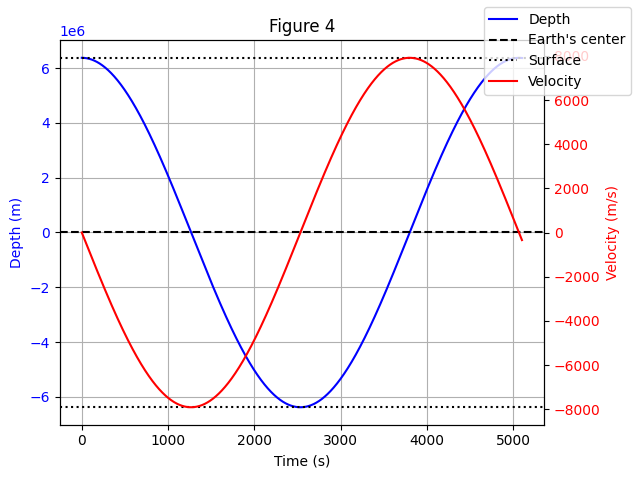

In [8]:
# Velocity derivative ODE (with height-dependent g)
def vel_deriv(t, init):
    y, v = init
    g = g_0 * y/R_E # height-dependent g
    dydt = v        # rate of change of depth
    dvdt = -g       # rate of change of velocity
    return (dydt, dvdt)

# Event trigger
def bottom(t, init):
    y, v = init
    return y
    
# Assign variables
t_0, t_f = 0, 5100
tt = np.linspace(t_0, t_f, 5101)
y_0 = R_E

# solve_ivp
soln = solve_ivp(vel_deriv, (t_0, t_f), [y_0, v_0], t_eval=tt, events=bottom)
t_vals = soln.t    # time
y_vals = soln.y[0] # depth
v_vals = soln.y[1] # velocity

t_soln = soln.t_events[0][0]
y_soln = soln.y_events[0][0][1]
print(f"Time to center:  {t_soln:.3f} seconds")
print(f"Time to surface: {2*t_soln:.3f} seconds")
print(f"Speed at center: {np.abs(y_soln):.3f} m/s")
print(f"Period:          {4*t_soln:.3f} seconds")

# Plot
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

ax1.plot(t_vals, y_vals, "b", label="Depth")
ax2.plot(t_vals, v_vals, "r", label="Velocity")
ax1.axhline(0, c="k", ls="--", label="Earth's center")
ax1.axhline(R_E, c="k", ls=":", label="Surface")
ax1.axhline(-R_E, c="k", ls=":")

# Label
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Depth (m)", c="b")
ax2.set_ylabel("Velocity (m/s)", c="r")

ax1.tick_params(axis="y", labelcolor="b")
ax2.tick_params(axis="y", labelcolor="r")

ax1.set_title("Figure 4")
ax1.grid(True)
fig.legend(loc="upper right")
fig.tight_layout()

In [9]:
T = np.sqrt(4*(np.pi**2)*(R_E**3) / (G*M_E)) # orbital period
print(f"Orbital Period: {T:.3f} seconds")

Orbital Period: 5069.371 seconds


The mass's depth as it changes with time follows a sinusoidal wave. It reaches the Earth's center after a fall time of 1266.473 seconds with a velocity of 7910.760 m/s. Because of the sinusoidal nature of the depth function, it will reach the opposite side of the earth after twice this time interval at 2532.947 seconds with a speed of 0 m/s (due to conservation laws). The period would be 4 times the time interval, therefore 5065.894 seconds for the mass to return to its original location. This is similar to the oribtal period of the object around the Earth of 5069.371 seconds

## Part 5: A non-uniform Earth

Finally, let us consider the case of a non-uniform Earth, and continue assuming we have no drag. We know from geology
that the density increases towards the center.
It rises from about 2-3 g/cm$^3$ near the surface, to more like 13 near the center.
A simple model for the density $\rho$ as a function of distance from the center of the Earth $r$ is:

$$
\rho(r) = \rho_n \left( 1 - \frac{r^2}{R_{\oplus}^2} \right)^n   \tag{8}
$$

where $n$ is some exponent, and $\rho_n$ is a normalizing constant.
The case of $n=0$ is the constant density Earth, while $n=2$ is closer to the real value.
Note that the total mass of the Earth, $M$, must be conserved.
Since the mass is the volume integral over the density:

\begin{equation}
        M = \int_V \rho(r) dV = \int_0^{2\pi} \int_0^{\pi} \int_0^{R_{\oplus}} \rho(r) r^2 \sin \phi \, dr \, d\phi \,d\theta = 4 \pi \int_0^{R_{\oplus}} \rho(r) r^2 \, dr
        \tag{9}
\end{equation}

you will need to recompute the density constant $\rho_n$ for each case of $n>0$,
You can use the `quad` integrator for this.
Note that the analytic solution is straightforward to do by hand for $n=0$,
and still manageable for $n=1,2$.
You might consider doing that integral to make sure your method is right, 
and then you can be confident for $n>0$.

1.  Plot the normalized density profile (that is, set $\rho_n=1$) as a function of radius for $n=0, 1, 2, 9$.            
              Put them all on the same plot, with a clear legend.       
              In your notebook, label this figure clearly as **Figure 5**.

2. Now, plot the force profile as a function of radius for $n=0, 1, 2, 9$.         
                This step will show you if your normalization factor $\rho_n$
                is correct, because the surface force must be the same for all $n$.       
              In your notebook, label this figure clearly as **Figure 6**.                

3. Then, plot the position and velocity as a function of time for $n=0, 1, 2, 9$
              as you did in Figure 1/2.         
              In your notebook, label this figure clearly as **Figure 7**.              

4. For $n=0, 1, 2, 9$, compute the time to reach the center, 
                and the speed achieved there.





### Part 5, Section A (Density)

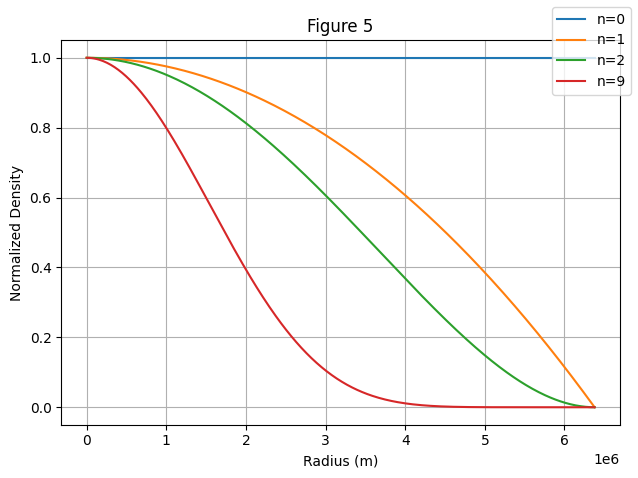

In [10]:
# Density function
def density(r, p_n, n):
    return p_n*((1-(r**2/R_E**2))**n)

# Assign variables
r_vals = np.linspace(0, R_E, 401)
pn_0 = 1 # density constant
n = [0, 1, 2, 9]

# Plot
fig, ax = plt.subplots()
for i in n:
    ax.plot(r_vals, density(r_vals, pn_0, i), label=f"n={i}")

# Label
ax.set_xlabel("Radius (m)")
ax.set_ylabel("Normalized Density")

ax.set_title("Figure 5")
ax.grid(True)
fig.legend(loc="upper right")
fig.tight_layout()

### Part 5, Section B (Forces)

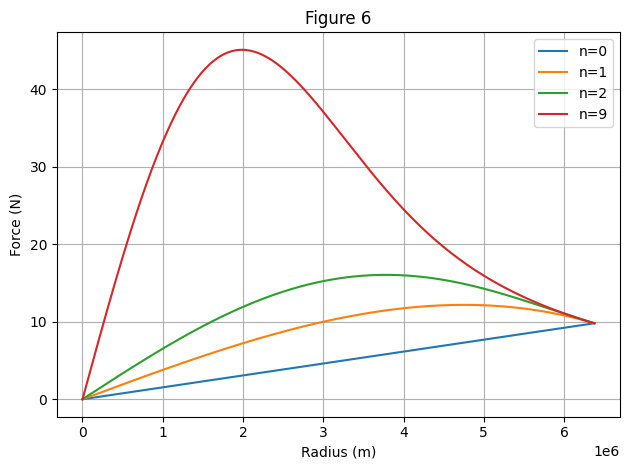

In [11]:
# Mass function
def mass(r, p_n, n):
    return 4*np.pi*density(r, p_n, n)*(r**2)

r_vals = np.linspace(1, R_E, 401) # avoid divide by zero error

# Plot
fig, ax = plt.subplots()
for i in n:
    # Find rho
    M_E_int = quad(mass, 0, R_E, args=(1, i))
    rho = M_E / M_E_int[0]

    # Compute force
    F = np.zeros(len(r_vals))
    for j, r in enumerate(r_vals):
        M_E_enc = quad(mass, 0, r, args=(rho, i))
        F[j] = G*M_E_enc[0]/(r**2)
    ax.plot(r_vals, F, label=f"n={i}")
    
# Label
ax.set_xlabel("Radius (m)")
ax.set_ylabel("Force (N)")

ax.set_title("Figure 6")
ax.grid(True)
ax.legend()
fig.tight_layout()

### Part 5, Section C (Equations of Motion)

n=0
Time to center:  1267.228 seconds
Speed at center: 7905.676 m/s

n=1
Time to center:  1096.509 seconds
Speed at center: 10462.057 m/s

n=2
Time to center:  1035.152 seconds
Speed at center: 12202.145 m/s

n=9
Time to center:  943.842 seconds
Speed at center: 18393.454 m/s



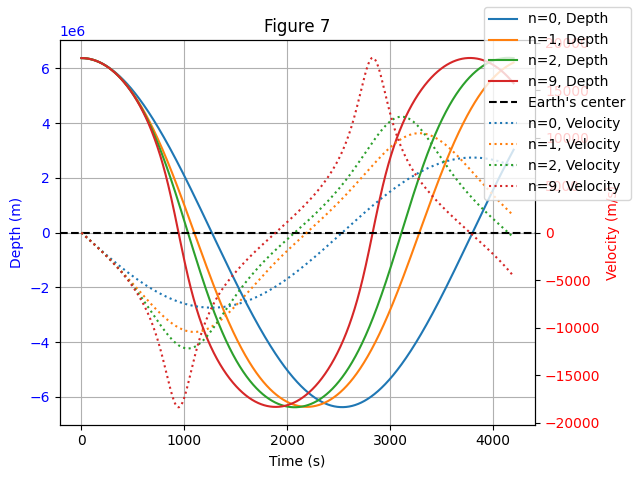

In [12]:
# Velocity derivative ODE (with height-dependent g)
def vel_deriv(t, init, rho, n):
    y, v = init
    M_E_enc = quad(mass, 0, R_E+y, args=(rho, n))
    g = G*M_E_enc[0]/((R_E+y)**2) # height-dependent g
    dydt = v                      # rate of change of depth
    dvdt = -g                     # rate of change of velocity
    return (dydt, dvdt)

# Event trigger
def bottom(t, init, rho, n):
    y, v = init
    return y + R_E

# Assign variables
t_0, t_f = 0, 4200
tt = np.linspace(t_0, t_f, 4201)
y_0 = 0

# Plot
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

for i in n:
    # Find rho
    M_E_int = quad(mass, 0, R_E, args=(1, i))
    rho_0 = M_E / M_E_int[0]

    # solve_ivp
    soln = solve_ivp(vel_deriv, (t_0, t_f), [y_0, v_0], args=(rho_0, i), t_eval=tt, events=bottom)
    t_vals = soln.t          # time
    y_vals = soln.y[0] + R_E # depth
    v_vals = soln.y[1]       # velocity

    t_soln = soln.t_events[0][0]
    y_soln = soln.y_events[0][0][1]
    print(f"n={i}\nTime to center:  {t_soln:.3f} seconds")
    print(f"Speed at center: {np.abs(y_soln):.3f} m/s\n")

    ax1.plot(t_vals, y_vals, label=f"n={i}, Depth")
    ax2.plot(t_vals, v_vals, ls=":", label=f"n={i}, Velocity")

ax1.axhline(0, c="k", ls="--", label="Earth's center")

# Label
ax1.set_xlabel("Time (s)")
ax2.set_xlabel("Time (s)")
ax1.set_ylabel("Depth (m)", c="b")
ax2.set_ylabel("Velocity (m/s)", c="r")

ax1.tick_params(axis="y", labelcolor="b")
ax2.tick_params(axis="y", labelcolor="r")

ax1.set_title("Figure 7")
ax1.grid(True)
fig.legend(loc="upper right")
fig.tight_layout()

## Part 6: A Lunar Mine Shaft


Finally, with all of the framework in place, consider the case where the
the mine shaft is instead dug on the moon.

1. Compute the travel time to the center of the moon
                in case we dig a pole-to-pole mine shaft,
                so that we can again avoid the Coriolis force, though
                on the moon this force is very small. No drag force either,
   which is actually realistic for the moon!
3. What is the density (if you asssume a constant density) 
                of the moon compared to that of earth? 
4. How does the fall/orbit time depend on density? See if you can discover a 
        relationship between the density and the fall time. You should think beyond strictly linear 
        relationships.



This problem can actually be
done on paper, and then you can compare the answer with that for the homogenous earth
you did in Part 4.


In [13]:
# Velocity derivative ODE (with height-dependent g)
def vel_deriv(t, init):
    y, v = init
    g = g_m * (R_m+y)/R_m # height-dependent g
    dydt = v              # rate of change of depth
    dvdt = -g             # rate of change of velocity
    return (dydt, dvdt)

# Event trigger
def bottom(t, init):
    y, v = init
    return y + R_m

# Assign variables
t_0, t_f = 0, 2000
tt = np.linspace(t_0, t_f, 2001)
g_m = G*M_m/(R_m**2)

# solve_ivp
soln = solve_ivp(vel_deriv, (t_0, t_f), [y_0, v_0], t_eval=tt, events=bottom)
t_soln = soln.t_events[0][0]
y_soln = soln.y_events[0][0][1]
print(f"Time to center:  {t_soln:.3f} seconds")
print(f"Speed at center: {np.abs(y_soln):.3f} m/s")

Time to center:  1624.928 seconds
Speed at center: 1679.982 m/s


In [14]:
# Solve for Moon's density
V_m = 4/3*np.pi*(R_m**3)
D_m = M_m/V_m
print(f"Density of the Moon:  {D_m:.3f} kg/m^3")

# Solve for Earth's density
V_E = 4/3*np.pi*(R_E**3)
D_E = M_E/V_E
print(f"Density of the Earth: {D_E:.3f} kg/m^3")

# Compare densities
print(f"The Moon's density {D_m/D_E:.3f} of the Earth's")

Density of the Moon:  3341.754 kg/m^3
Density of the Earth: 5494.867 kg/m^3
The Moon's density 0.608 of the Earth's


Given the equation of the force due to gravity is found by $F_g=\frac{GMm}{r^2}$ we can set this equal $F=ma$ therefore getting $a=\frac{GM}{r^2}$

To connect this to density, we know that density is found by $D=M/V$ where $V=\frac{4}{3}\pi\,r^3$ then substituting and rearranging we get $M=\frac{4}{3}\pi\,Dr^3$

We can now substitute this equation for mass into the equation for the acceleration due to gravity, getting $a=\frac{GDV}{r^2}$ and further $a=\frac{4}{3}\pi\,GDr$

To find the fall time we must realize that this acceleration changes with distance, and therefore we cannot use kinematic equations

Because this object is falling in a straight line, we use the property $a = v\frac{dv}{dr}$ and substituting in the acceleration $v\,dv=\frac{4}{3}\pi\,GDr\,dr$ we then integrate both sides to get $\frac{v^2}{2}=\frac{2}{3}\pi\,GD(r^2-R^2)$

The next step is to isolate the velocity because we know $v=\frac{dr}{dt}$ and that is how we bring in time to the problem. This gives us $v=\frac{dr}{dt}=-\sqrt{\frac{4}{3}\pi\,GD(R^2-r^2)}$

We can now isolate and solve for time $\int_{0}^{T}\,dt=\int_{R}^{0}\frac{-dr}{\sqrt{\frac{4}{3}\pi\,GD(R^2-r^2)}}$

This results in the final equation $t = \frac{\pi}{2}\sqrt{\frac{3}{4\pi\,GD}}$

In [15]:
t_E = np.pi/2 * np.sqrt(3/(4*np.pi*G*D_E))
t_m = np.pi/2 * np.sqrt(3/(4*np.pi*G*D_m))

print(f"Time to center (Earth): {t_E:.3f} seconds")
print(f"Time to center (Moon):  {t_m:.3f} seconds")

Time to center (Earth): 1267.343 seconds
Time to center (Moon):  1625.120 seconds


These results are similar to the previous results of 1266.473 seconds (Earth) and 1624.928 seconds (Moon)

## Part 7: Fourier Transforming Orbits

Take the solutions for n=0 and n=9 of the orbits in Part 5 (the inhomogeneous earth) and Fourier Transform them, to see what frequencies (*1/periods*) are dominant in the power spectra. Comment on what you see.

**Hint:** you could take the orbit from the previous integration in Part 5c, but it is useful to increase the integration time and sampling to get more meaningful smooth enough curves. We discussed this in class.

For an example of a spectral analysis of galactic orbits see https://articles.adsabs.harvard.edu/pdf/1982ApJ...252..308B

In [16]:
# Velocity derivative ODE (with height-dependent g)
def vel_deriv(t, init, rho, n):
    y, v = init
    M_E_enc = quad(mass, 0, R_E+y, args=(rho, n))
    g = G*M_E_enc[0]/((R_E+y)**2) # height-dependent g
    dydt = v                      # rate of change of depth
    dvdt = -g                     # rate of change of velocity
    return (dydt, dvdt)

# Event trigger
def bottom(t, init, rho, n):
    y, v = init
    return y + R_E

# Assign variables
t_0, t_f = 0, 15_000
tt = np.linspace(t_0, t_f, 15_000_001)
dt = tt[1] - tt[0]
n = [0, 9]
res = {}

for i in n:
    # Find rho
    M_E_int = quad(mass, 0, R_E, args=(1, i))
    rho_0 = M_E / M_E_int[0]

    # solve_ivp
    soln = solve_ivp(vel_deriv, (t_0, t_f), [y_0, v_0], args=(rho_0, i), t_eval=tt, events=bottom)

    # Store results
    res[i] = {
        "t_vals": soln.t,          # time
        "y_vals": soln.y[0] + R_E, # depth
        "period": np.abs(4*soln.t_events[0][0]) # period
    }

    period = res[i]["period"]
    print(f"n={i}\nFrequency: {1/period:.5f} Hz")
    print(f"Period:    {period:.2f} seconds\n")

n=0
Frequency: 0.00020 Hz
Period:    5068.91 seconds

n=9
Frequency: 0.00026 Hz
Period:    3775.37 seconds



n=0
Peak Frequency: 0.00020 Hz
Period:         5000.00 seconds

n=9
Peak Frequency: 0.00027 Hz
Period:         3750.00 seconds



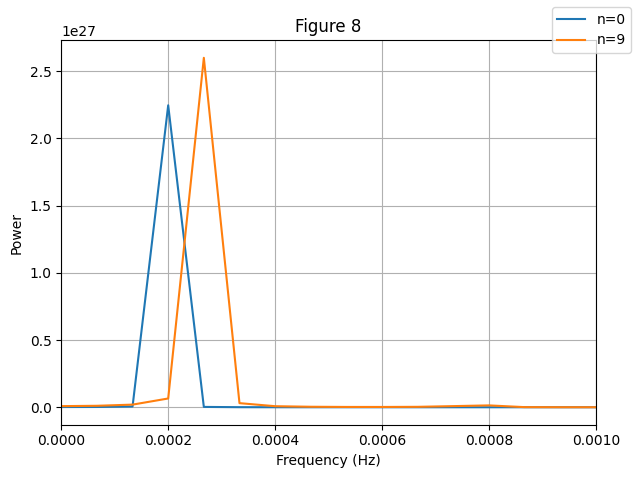

In [17]:
fig, ax = plt.subplots()

for i in n:
    t_vals, y_vals, period = res[i].values() # unpack dictionary

    # Compute frequencies and power
    N = len(y_vals)
    freq = rfftfreq(N, dt)
    power = np.abs(rfft(y_vals))**2

    # Plot
    ax.plot(freq, power, label=f"n={i}")

    # Compute peak frequency
    max_freq = freq[np.argmax(power)]
    print(f"n={i}\nPeak Frequency: {max_freq:.5f} Hz")
    print(f"Period:         {1/max_freq:.2f} seconds\n")

# Label
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Power")
ax.set_xlim(0, 0.001)

ax.set_title("Figure 8")
ax.grid(True)
fig.legend(loc="upper right")
fig.tight_layout()

The periods that were found from the solve_ivp function are more accurate than the periods found from the Fourier Transform. This is likely because of a computational limit in the function fft functions being hit.